In [1]:
from pyhipp import plot
from sidm.yangyao import profiles, models
import numpy as np

## The cosmology and unit system

In [2]:
cosm = profiles.default_cosm
cosm.params

[ {'name': 'hubble', 'value': 0.6774}, {'name': 'omega_m0', 'value': 0.3089},
  {'name': 'omega_l0', 'value': 0.6911}, {'name': 'omega_b0', 'value': 0.0486},
  {'name': 'sigma_8', 'value': 0.8159}, {'name': 'n_spec', 'value': 0.9667},
  {'name': 't_cmb', 'value': 2.7255}]

In [3]:
us = cosm.unit_system
us

{ 'u_l': '4.555178006335056e+22 m',
  'u_t': '4.658635961027458e+16 s',
  'u_m': '2.935355581189919e+40 kg',
  'u_v': '977792.2216807893 m / s'}

By default, the cosmology and the corresponding unit system in used are the 
default ones shown above. The elements of units are: $10^{10}{\rm M}_\odot/h$, ${\rm Gyr}/h$, and ${\rm Mpc}/h$.

In [12]:
M_v = 1.0e12 / us.u_m_to_sol                            # a halo with mass 10^12 Msun, converted to default unit
R_v = cosm.halo_theory.vir_props_crit(M_v, z=0.).r_phy  # physical virial radius
print(f'{M_v=}, {R_v=}')

M_v=np.float64(67.74000000000001), R_v=np.float64(0.14282429654564824)


In [13]:
R_v * us.u_l_to_pc, M_v * us.u_m_to_sol                 # convert back to pc and Msun

(np.float64(210841.8903833012), np.float64(1000000000000.0))

## Profiles



Here we plot the profile and rotation curve of an NFW halo.

In [16]:
halo = profiles.NFW(M_v, R_v, c=10)

[ <pyhipp.plot.axes.Axes object at 0x349f24290>,

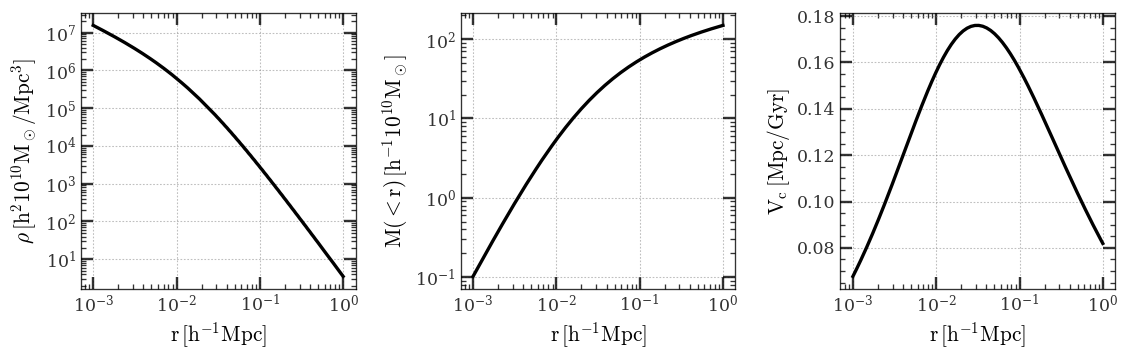

In [23]:
# compute profiles
rs = np.logspace(-3., 0., 128)                          # 0.001 to 1 Mpc/h
lg_rs = np.log10(rs)

pf = halo.profile._impl
rhos = pf.rhos(lg_rs)                                   # density
Ms = pf.M_encs(lg_rs)                                   # enclosed mass

rot = halo.rotation._impl
Vc = np.sqrt(rot.Vc_sqs(lg_rs))                         # circular velocity

fig, axs = plot.subplots((1,3), share=False)
axs_f = axs.flat

ax = axs_f[0]
ax.plot(rs, rhos).label(r'r\,[h^{-1}{\rm Mpc}]', r'\rho\,[h^2{\rm 10^{10}M_\odot/Mpc^3}]')

ax = axs_f[1]
ax.plot(rs, Ms).label(r'r\,[h^{-1}{\rm Mpc}]', r'M(<r)\,[h^{-1}{\rm 10^{10}M_\odot}]')

ax = axs_f[2]
ax.plot(rs, Vc).label(r'r\,[h^{-1}{\rm Mpc}]', r'V_c\,[{\rm Mpc/Gyr}]')

axs.scale('log')
axs[:2].scale(y='log')